### **TP2_Data_Analysis_Notebook for students**

During this session we will work on **real VSDI images  obtained from the primary somatosensory cortex from the rat**

I invite you to read the following paper 
**[Grinvald (2004) VSDI a new era in functional imaging of cortical dynamics](http://wexler.free.fr/library/files/grinvald%20(2004)%20vsdi.%20a%20new%20era%20in%20functional%20imaging%20of%20cortical%20dynamics.pdf)**


**Description of the experiment :** 

In the anasthetized rat, you are interested in studying the dynamic of tactile evoked responses in the primary somatosensory cortex.

Brief tactile stimulations (duration of a stimulus = 2
ms) were randomly applied on the finger tip (digit 2,3,4 or 5) of the rat forehand, about 1 stimulus per 20 second. 

Emitted VSDI fluorescence was recorded. During a trial, one image was acquired every 3 ms, 256 times. One trial = 256 images each 3ms then 768 ms of duration for a trial.

As usual, like for **any imaging method**, one has to **compare a 'test' trial (with stimulus) to a control trial**

Alternatively, stimulation and control trials were acquired. 

A file can contain data from a stimulation trial or a control trial (acquisition of the same amount of images without tactile stimulation)

For example the file named T1-B2R10-0419-616 contains the images of a trial with a stimulation while the file named T1-B2R10-0419-617 contains control images with stimulation (acquisition of the same amount of images without tactile stimulation).


During a trial with stimulation, the stimulus was applied 100 ms after beginning of image acquisition. The stimulus was then applied at frame (image) 33. 


Each file named "T1-B2R10-0419-..." contains the same variable:

- **Evok** : Fluorescence signal for the 10 000 pixels of each 256 images of one acquisition (10 000 pixels $*$ 256 images)
            
            
The file MANIP120419_2 contains : 

- **Block** : stimulus of the list of trial



### **Starting**

First step, 
**Drop all the needed file into your main directory**

**Just run the following section** in order to open and convert the lists Evok into a 100 pixels $*$ 100 pixels $*$ 256 images array, for a stimulus trial and a control trial, to open the file containing the identification of the trial (which finger had been stimulated) and to open cortex image

Text(0.5, 1.0, 'Imaged Part of the Cortex over the primary somatosensory cortex')

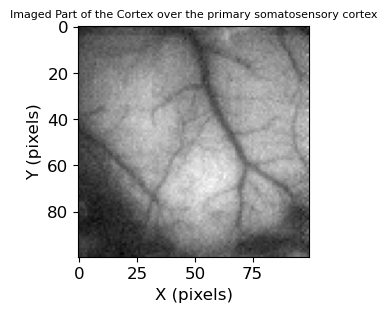

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy.io import loadmat
import matplotlib as mpl
mpl.rcParams['font.size'] =12

#open file with identification of the trial
DataUnit=loadmat('MANIP120419_2')  
ListCond=DataUnit["block"]
ListCond=ListCond[0]

##choose the trial you want to see 
fileIDinit=616
trialID=1

fileID=fileIDinit+2*trialID-2

##Open image files and converted into a 100 pixels * 100 pixels * 256 images array
Data=loadmat('T'+str(trialID)+'-B2R10-0419-'+str(fileID))  
Stim=Data["Evok"].reshape((100,100,255))
Data=loadmat('T'+str(trialID)+'-B2R10-0419-'+str(fileID+1))  
Control=Data["Evok"].reshape((100,100,255))
#open cortex image
Cortex=loadmat('GREEN_MANIP120419')  
Cortex=Cortex["gr"]

fig,axs = plt.subplots(1, 1, figsize=(5, 3))
axs.imshow(Cortex)
axs.set_xlabel('X (pixels)')
axs.set_ylabel('Y (pixels)')
axs.set_title('Imaged Part of the Cortex over the primary somatosensory cortex',fontsize=8)



*Stim* is now a 3D matrix of 100 $*$ 100 $*$ 256. 256 images of 100 $*$ 100 pixels.

Same applies for *Control*

Then *Stim[:,:,0]* is the first image of *Stim*.
*Stim[50,50,:]* will give you the signal over time for the pixel in the center of the image.

**To do list:**

* Visualize the image 40 of the *stim* trial and the image 40 of the *control* trial (use imshow) - 2 min - 
* For one choosen pixel, plot the signal (fluorescence F) as a function of time (from 0 to 256 images) for the stim trial and the control trial on the same plot with different color - 2 min - 
* Explain why it is important to compare both. 
* Calculate a new 3DArray with is the result of (Stim-Control)/Control. This ratio called  ***DF/F***. - 5 min - 
* For one choosen pixel, plot the *DF/F* as a function of time (from 0 to 256 images) - 2 min - 
* Visualize the image 40 of *DF/F* - 2 min -
* Using a gaussian filter, filter the images  (function : gaussian_filter), visualize the image 40 of *DF/F* filtered with a kernel of 2,3,4 and 5 (make a subplot of 1 line and 4 plots) - 20 min -
* On one figure, show on the 2 rows (subplot(2,10)) - 10 min -
    *  10 following *DF/F*  non filtered images (image 37 to 46) on one row
    *  10 following *DF/F*  filtered images (image 37 to 46) on a second row
* plot the *DF/F* as a function of time for a pixel located the region of activation and plot on the same axes, the mean *DF/F* of a group of pixel (ROI : region of interest)  - 15 min -

